## Preprocessing of the data

Preprocessing of both Petkovich and Thompson data was done by Evgeniy Efimov. The steps are described in ..?

## Import libraries

In [2]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from sklearn.cluster import DBSCAN
from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, root_mean_squared_error

# Training and testing Petkovich cluster-based and CpG-based clocks on the Petkovich dataset

## Read data

For some reason, `GSE80672_metlevs_processed.parquet.gz` does not contain some of the samples from the original GEO ('GSM2132821', 'GSM2132831', 'GSM2132846', 'GSM2132859', 'GSM2132894', 'GSM2132941', 'GSM2132943', 'GSM2132951', 'GSM2132959')

In [3]:
# Read Petkovich et al. (2017) methylation levels and metadata 
parquet_cols = set(
    pq.read_schema(
        "../sources/Petkovich_GSE80672_Efi_processed/GSE80672_metlevs_processed.parquet.gz"
    ).names
)

petkovich_meta = (
    pd.read_csv(
        "../sources/Petkovich_GSE80672_Efi_processed/GSE80672_metadata_cleaned.csv"
    )
    .query("ID.str.match(r'^M(?!I)')")
    .rename(columns={"Unnamed: 0": "GSE"})
    .reset_index(drop=True)
)

valid_ids = [gse for gse in petkovich_meta["GSE"] if gse in parquet_cols]

petkovich_meta = petkovich_meta[petkovich_meta["GSE"].isin(valid_ids)].reset_index(
    drop=True
)
petkovich = pd.read_parquet(
    "../sources/Petkovich_GSE80672_Efi_processed/GSE80672_metlevs_processed.parquet.gz",
    columns=valid_ids,
)

## Use DBSCAN to cluster methylation sites

### Do clastering with DBSCAN

In [4]:
# 1. Divide site index into chromosome and position
site_coords = pd.DataFrame(
    {
        "chrom": petkovich.index.str.rsplit("_", n=1).str[0],
        "pos": petkovich.index.str.rsplit("_", n=1).str[1].astype(int),
    },
    index=petkovich.index,
)

all_labels = pd.Series(index=petkovich.index, dtype=object)

# 2. Apply DBSCAN separately for each chromosome
eps = 1000  # maximum distance in bp between neighboring CpGs to be in the same cluster (as in the original paper)
min_samples = 5  # minimum number of sites in a cluster (as in the original paper)

all_labels = pd.Series(index=petkovich.index, dtype=object)

cluster_offset = 0  # to ensure unique cluster labels across chromosomes

for chrom, group in site_coords.groupby("chrom"):
    positions = group["pos"].values.reshape(-1, 1)

    db = DBSCAN(eps=eps, min_samples=min_samples, metric="euclidean")
    labels = db.fit_predict(positions)

    mask_not_noise = labels != -1
    labels_shifted = labels.copy()
    # DBSCAN returns -1 for noise (sites that are not in clusters)
    # Shift cluster labels to be globally unique
    labels_shifted[mask_not_noise] += cluster_offset

    all_labels[group.index] = labels_shifted

    if mask_not_noise.any():
        cluster_offset += labels[mask_not_noise].max() + 1

site_coords["cluster"] = all_labels


### Calculate mean methylation level for each cluster

During the preprocesing step, all the methylation sites that had coverage <= 5 were handled as NaN. Therefore, some of the enteries in `petkovich` dataframe are NaN. Since the whole philosophy of clustering and calculating using the cluster mean is based on the assumption that neighbouring sites have the same methylation status, we can ignore these NaN values when calculating the mean methylation level for each cluster.

This approach repicates one that was used in the Simpson et al. (2023) paper.

However, this approach has a room for improvement. If a cluster has too many NaN values, it may not be reliable to calculate the mean methylation level for that cluster. In such cases, we can set a threshold for the maximum allowed percentage of NaN values in a cluster. If the percentage of NaN values exceeds this threshold, we can choose to exclude that cluster from further analysis. I haven't implemented this approach yet, but it is something that can be considered in the future.

In [5]:
clustered_sites = site_coords[site_coords["cluster"] != -1]

# Calculate mean methylation level per cluster per sample
cluster_petkovich = (
    petkovich.loc[clustered_sites.index]
    .groupby(clustered_sites["cluster"])
    .mean(skipna=True)
)

print(f"Total number of clusters: {len(cluster_petkovich)}")
print(f"Removed : {(site_coords['cluster'] == -1).sum()}")
cluster_sizes = clustered_sites.groupby("cluster").size()
print(f"Median cluster size: {cluster_sizes.median():.0f} CpG")


Total number of clusters: 57065
Removed : 172402
Median cluster size: 9 CpG


### NaN imputation for cluster methylation values

I couldn't get how Simpson et al. (2023) dealed with NaN values. Unfortunately, they haven't uploaded code with their analysis anywhere. Therefore, I can only speculate:
According to the 4.6. in the Methods section they say: "Regions with NaN (i.e. no reads recorded) were removed." My understanding: If any sample has NaN in a given cluster, this cluster is removed from all the samples. This approach removes 1577 clusters, which is not that much.

In [6]:
print(f"Total number of clusters after removing NaNs: {cluster_petkovich.shape[0] - cluster_petkovich.isna().any(axis=1).sum()}")
cluster_petkovich_clean = cluster_petkovich.dropna(axis=0, how="any")

Total number of clusters after removing NaNs: 55488


For the initial dataset with separate CpG sites, removing all sites that have at least a single NaN value would be quite strict (it would remove 280792 sites - around 17% of all sites). The authors' approach to this problem is, again, unclear.

Since we will use LASSO regression for age prediction, which will significantly reduce the number of features anyway, we can remove all sites that have at least a single NaN value. 

In [7]:
print(
    f"Total number of CpGs after removing NaNs: {petkovich.shape[0] - petkovich.isna().any(axis=1).sum()}"
)
petkovich_clean = petkovich.dropna(axis=0, how="any")

Total number of CpGs after removing NaNs: 912259


## LASSO regression for age prediction

### Prepare the data 

In [8]:
# Create a dictionary mapping each age to the list of samples with that age
sample_to_age = petkovich_meta.set_index("GSE")["Age"]
age_groups = (
    sample_to_age.groupby(sample_to_age).apply(lambda x: x.index.tolist()).to_dict()
)

# Prepare data for modeling
X_cpg = petkovich_clean.T
X_reg = cluster_petkovich_clean.T
y = sample_to_age[X_cpg.index].astype(float)

### Perform nested cross-validation for both CpG-based and cluster-based models

Apparently, in the Simpson et al. (2023) paper, they didn't use nested cross-validation for testing the performance of their model. They just used a single train-test split. I will implement nested cross-validation, which is a more robust and will allow us to compare the performance of CpG-based and cluster-based models more reliably.

In [ ]:
def nested_cv(X, y, k=5):
    """
    Nested cross-validation with LassoCV.
    Outer loop (k folds): evaluates model performance (R², RMSE).
    Inner loop (k folds): LassoCV selects optimal alpha via MSE.
    """

    # Inner CV handles alpha selection, outer CV handles model evaluation
    inner_cv = KFold(n_splits=k, shuffle=True, random_state=42)
    outer_cv = KFold(n_splits=k, shuffle=True, random_state=42)

    model = LassoCV(cv=inner_cv, max_iter=10000, random_state=42)

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=outer_cv,
        scoring=["r2", "neg_root_mean_squared_error"],
        n_jobs=-1,
        return_estimator=True,
    )

    # Out-of-fold predictions for plotting
    oof_pred = cross_val_predict(model, X, y, cv=outer_cv)

    return {
        "Mean R2": cv_results["test_r2"].mean(),
        "Mean RMSE": -cv_results["test_neg_root_mean_squared_error"].mean(),
        "Avg Features": np.mean(
            [sum(est.coef_ != 0) for est in cv_results["estimator"]]
        ),
        "Best Alphas": [est.alpha_ for est in cv_results["estimator"]],
        "oof_pred": oof_pred,
        "y_true": y.values,
    }


In [106]:
results_reg = nested_cv(X_reg, y)
print(f"""
    Region Clock:
    Mean R2: {results_reg["Mean R2"]}
    Mean RMSE: {results_reg["Mean RMSE"]}
    Avg Features: {results_reg["Avg Features"]}
""")



    Region Clock:
    Mean R2: 0.950425229203816
    Mean RMSE: 2.1073110835894893
    Avg Features: 78.4



In [ ]:
results_cpg = nested_cv(X_cpg, y)
print(f"""
    CpG Clock:
    Mean R2: {results_cpg["Mean R2"]}
    Mean RMSE: {results_cpg["Mean RMSE"]}
    Avg Features: {results_cpg["Avg Features"]}
""")

CpG Clock: {'Mean R2': np.float64(0.9292944121923885), 'Mean RMSE': np.float64(2.532475475023755), 'Avg Features': np.float64(105.2), 'Best Alphas': [np.float64(0.03407928760747331), np.float64(0.0026409744934363204), np.float64(0.003695147128425954), np.float64(0.013438240391773463), np.float64(0.004277738587016254)], 'oof_pred': array([ 3.05710751,  4.70457025,  1.62530292,  2.99027139,  4.28807913,  3.2467138 ,  3.26521252,  4.59278385,  6.3308805 ,  5.90267186,  3.6276178 ,  6.60490862,  5.32236244,  3.3458051 ,  3.15046756,  5.23226574,
        7.50385128,  9.86187776,  8.47620693,  8.59423351,  6.95875612,  7.16584545,  9.04500726,  5.41838191, 10.32669503, 11.31855446,  7.18331045,  9.09886939, 12.85422758,  8.21884457, 10.9252218 ,  8.70188006,
        8.85065289,  9.18058734, 13.47220221, 13.05502888,  8.37763602, 12.67795866, 10.39428385, 11.28006123, 14.44831841, 12.24874105, 16.80808989, 12.90640644, 14.42197798, 13.3031733 , 13.42725177, 11.36183464,
       10.59620044, 11

Save the results

In [ ]:
# with open(
#     "../outputs//01_petkovich_blood_clocks/petkovich_on_petkovich_cpg_nestedCV_results.pkl", "wb"
# ) as f:
#     pickle.dump(results_cpg, f)
# with open(
#     "../outputs/01_petkovich_blood_clocks/petkovich_on_petkovich_cluster_nestedCV_results.pkl", "wb"
# ) as f:
#     pickle.dump(results_reg, f)

In [23]:
with open(
    "../outputs//01_petkovich_blood_clocks/petkovich_on_petkovich_cpg_nestedCV_results.pkl",
    "rb",
) as f:
    results_cpg = pickle.load(f)
with open(
    "../outputs/01_petkovich_blood_clocks/petkovich_on_petkovich_cluster_nestedCV_results.pkl",
    "rb",
) as f:
    results_reg = pickle.load(f)


### Plot the results

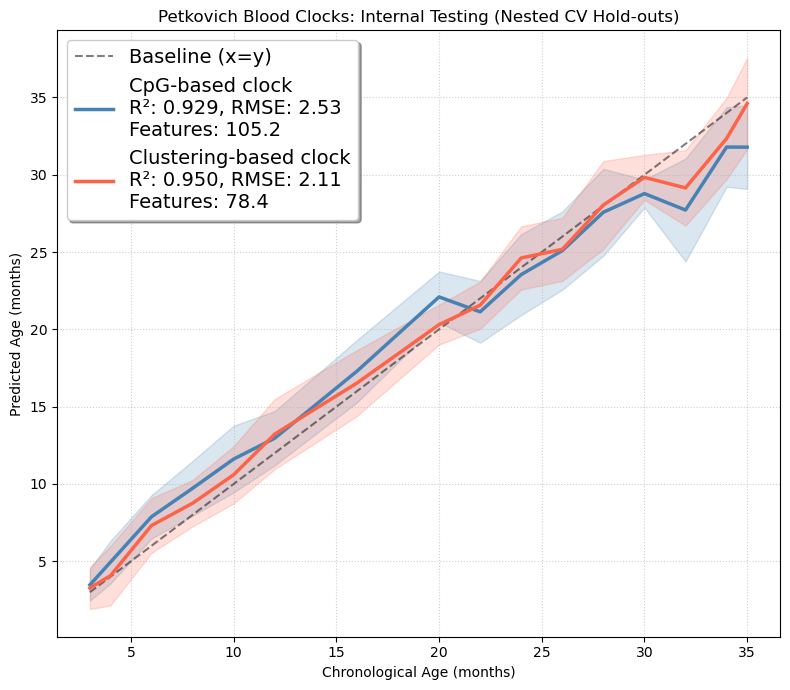

In [ ]:
def plot_clocks(res_cpg, res_reg, y):
    """Plot predicted vs real age with metrics and std bands."""
    plt.figure(figsize=(8, 7))

    # Baseline
    lims = [y.min(), y.max()]
    plt.plot(lims, lims, "--k", alpha=0.5, label="Baseline (x=y)")

    for res, name, color in [
        (res_cpg, "CpG-based clock", "steelblue"),
        (res_reg, "Clustering-based clock", "tomato"),
    ]:
        # Group predictions by actual age
        stats = (
            pd.Series(res["oof_pred"], index=y.index)
            .groupby(y)
            .agg(["mean", "std"])
            .fillna(0)
        )

        # Legend label with metrics
        lbl = f"{name}\nR²: {res['Mean R2']:.3f}, RMSE: {res['Mean RMSE']:.2f}\nFeatures: {res['Avg Features']:.1f}"

        # Plot lines and halos
        plt.plot(stats.index, stats["mean"], color=color, label=lbl, lw=2.5)
        plt.fill_between(
            stats.index,
            stats["mean"] - stats["std"],
            stats["mean"] + stats["std"],
            alpha=0.2,
            color=color,
        )

    plt.xlabel("Chronological Age (months)"), plt.ylabel("Predicted Age (months)")
    plt.title("Petkovich Blood Clocks: Internal Testing (Nested CV Hold-outs)")
    plt.legend(loc="upper left", frameon=True, shadow=True, fontsize=14)
    plt.grid(True, ls=":", alpha=0.6)
    plt.tight_layout(), plt.show()


# Run visualization
plot_clocks(results_cpg, results_reg, y)


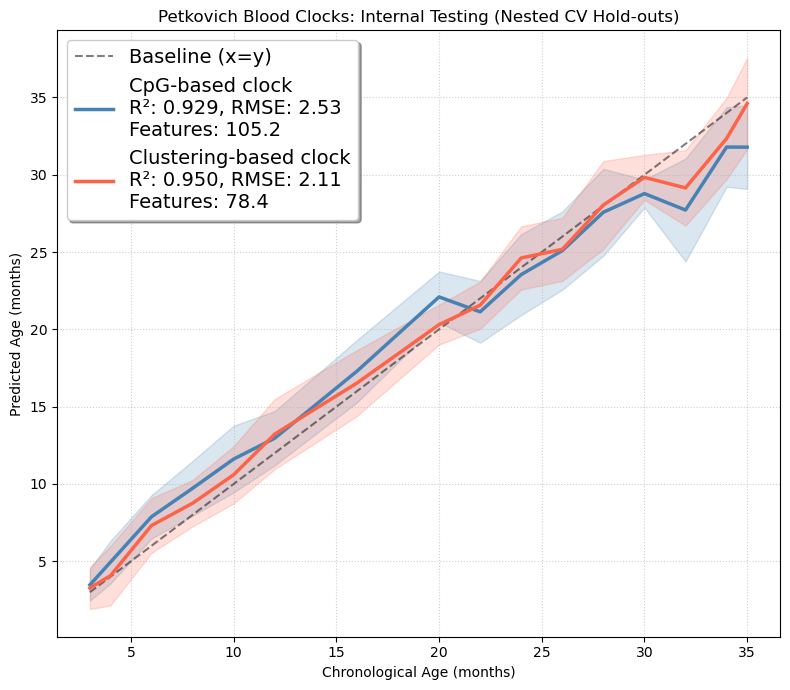

In [ ]:
_show = plt.show
plt.show = lambda: None

plot_clocks(results_cpg, results_reg, y)
plt.savefig(
    "../outputs/01_petkovich_blood_clocks/petkovich_on_petkovich_plot.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show = _show
plt.show()


## Training the final model that will be used for testing on external datasets

As the last step, we will train the final model on 100% of the data.

In [127]:
final_cpg_model = LassoCV(cv=5, max_iter=10000, n_jobs=-1, random_state=42)
final_cpg_model.fit(X_cpg, y)
print(f"Final optimal alpha for CpG-based model: {final_cpg_model.alpha_}")
print(f"Final model non-zero features for CpG-based model: {(final_cpg_model.coef_ != 0).sum()}")

final_reg_model = LassoCV(cv=5, max_iter=10000, n_jobs=-1, random_state=42)
final_reg_model.fit(X_reg, y)
print(f"Final optimal alpha for cluster-based model: {final_reg_model.alpha_}")
print(f"Final model non-zero features for cluster-based model: {(final_reg_model.coef_ != 0).sum()}")


with open(
    "../outputs/01_petkovich_blood_clocks/petkovich_cpg_lasso_full_model.pkl", "wb"
) as f:
    pickle.dump(final_cpg_model, f)
with open(
    "../outputs/01_petkovich_blood_clocks/petkovich_cluster_lasso_full_model.pkl", "wb"
) as f:
    pickle.dump(final_reg_model, f)

Final optimal alpha for CpG-based model: 0.002582694881522348
Final model non-zero features for CpG-based model: 145
Final optimal alpha for cluster-based model: 0.013801915174471997
Final model non-zero features for cluster-based model: 76


## Possible but skipped steps

### Fitering features by correlation with age

In order for LASSO to run faster, one can prefilter the features by calculating the correlation between each feature and the target variable (age) and selecting only those features that have an absolute correlation above a certain threshold. This approach is based on the assumption that features that are not correlated with the target variable are unlikely to be useful for prediction. However, this approach could lead to the data leakage, since we are using the whole dataset to calculate the correlation. To avoid it, I decided not to use this step.

Note: this approach was not used in the Simpson et al. (2023) paper.

/data/user/pgrobush/miniforge3/envs/semen/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/data/user/pgrobush/miniforge3/envs/semen/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


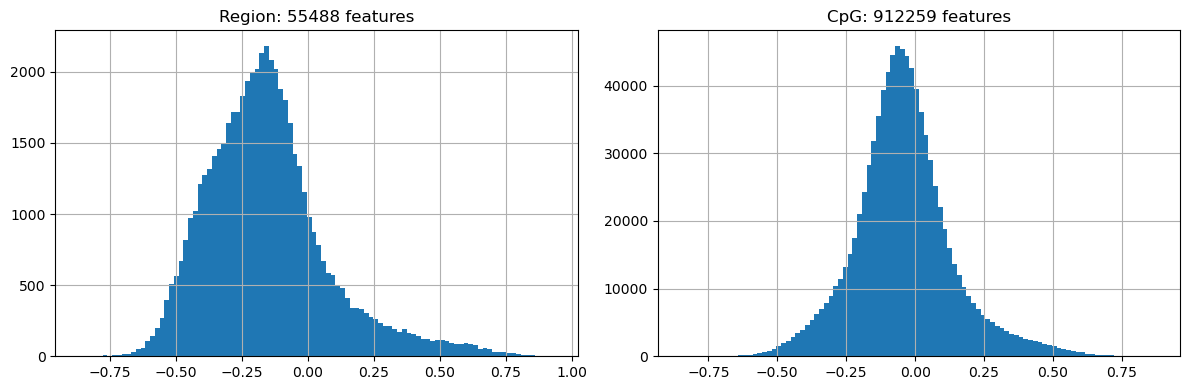

Region |r| > 0.3: 17722
Region |r| > 0.4: 8844
Region |r| > 0.5: 3132
Region |r| > 0.6: 865
Region |r| > 0.7: 224
CpG |r| > 0.3: 98283
CpG |r| > 0.4: 40229
CpG |r| > 0.5: 12569
CpG |r| > 0.6: 2903
CpG |r| > 0.7: 587


In [ ]:
# cors_reg = X_reg.corrwith(y)
# cors_cpg = X_cpg.corrwith(y)

# # Plot distributions
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# for ax, cors, name in zip(axes, [cors_reg, cors_cpg], ["Region", "CpG"]):
#     cors.hist(ax=ax, bins=100)
#     ax.set_title(f"{name}: {len(cors)} features")
# plt.tight_layout()
# plt.show()

# # Count features above thresholds
# for name, cors in [("Region", cors_reg), ("CpG", cors_cpg)]:
#     for thr in [0.3, 0.4, 0.5, 0.6, 0.7]:
#         print(f"{name} |r| > {thr}: {(cors.abs() > thr).sum()}")


In [ ]:
# # Filter features based on correlation (we use 0.3 as a threshold)
# threshold = 0.3

# X_reg_filtered = X_reg.loc[:, cors_reg.abs() > threshold]
# X_cpg_filtered = X_cpg.loc[:, cors_cpg.abs() > threshold]

# Testing Petkovich cluster-based and CpG-based clocks on the external Thompson dataset

## Read and prepare the data

### Read the data
Since we have trained our models on the blood methylation data from the Petkovich dataset, we will leverage only the blood methylation data from the Thompson dataset for testing. 

In [9]:
# Read Thompson et al. (2018) methylation levels and metadata (blood samples only)
parquet_cols = set(
    pq.read_schema(
        "../sources/Thompson_GSE120132_Efi_processed/GSE120132_metlevs_processed.parquet.gz"
    ).names
)

thompson_meta = (
    pd.read_csv(
        "../sources/Thompson_GSE120132_Efi_processed/GSE120132_metadata_cleaned.csv"
    )
    .query("Tissue == 'Blood'")
    .rename(columns={"Unnamed: 0": "GSE"})
    .reset_index(drop=True)
)

valid_ids = [gse for gse in thompson_meta["GSE"] if gse in parquet_cols]

thompson_meta = thompson_meta[thompson_meta["GSE"].isin(valid_ids)].reset_index(
    drop=True
)
thompson = pd.read_parquet(
    "../sources/Thompson_GSE120132_Efi_processed/GSE120132_metlevs_processed.parquet.gz",
    columns=valid_ids,
).T

### Retain only the features that were used in the Petkovich dataset

For cluster-based model, we will retain only those clusters that were used in the Petkovich dataset.

In [10]:
# 1. Keep only sites that are in both the clusters mapping and Thompson columns
active = clustered_sites[
    clustered_sites["cluster"].isin(X_reg.columns)
    & clustered_sites.index.isin(thompson.columns)
]

# 2. Print summary
print(
    f"Clusters: {active['cluster'].nunique()} out of {len(X_reg.columns)} clusters from Petkovich dataset are present in Thompson dataset"
)
print(f"Sites: {len(active)}")

# 3. Aggregate: transpose -> group by cluster -> mean -> transpose back
X_thompson_reg = (
    thompson[active.index]
    .T.assign(cluster=active["cluster"])
    .groupby("cluster")
    .mean()
    .T.reindex(columns=X_reg.columns)
)

Clusters: 48256 out of 55488 clusters from Petkovich dataset are present in Thompson dataset
Sites: 621791


If the Thompson dataset does not have any of the clusters that are used by the model trained on the Petkovich dataset, we will impute the missing cluster values with the mean methylation level of that cluster in the Petkovich dataset. This approach is based on the assumption that the mean methylation level of a cluster in the Petkovich dataset can serve as a reasonable estimate for the missing cluster values in the Thompson dataset. 

In [ ]:
# Precompute means
petkovich_cluster_means = X_reg.mean().values.astype("float64")
thompson_reg_vals = X_thompson_reg.values.astype("float64")

# Fill partial NaNs with Thompson column means
col_means = np.nanmean(thompson_reg_vals, axis=0)
nan_mask = np.isnan(thompson_reg_vals)
thompson_reg_vals[nan_mask] = np.take(col_means, np.where(nan_mask)[1])

# Remaining NaNs are fully absent clusters — fill with Petkovich means
still_nan = np.isnan(thompson_reg_vals)
thompson_reg_vals[still_nan] = np.take(petkovich_cluster_means, np.where(still_nan)[1])

X_thompson_reg_np = thompson_reg_vals
print(f"Remaining NaNs: {np.isnan(X_thompson_reg_np).sum()}")

We will do the same to prepare Thompson CpG features for testing the CpG-based model. I'm changing `float64` to `float32` for the faster calculation, because in the CpG data we have much more features. 

In [17]:
# Precompute means
petkovich_cpg_means = X_cpg.mean().values.astype("float64")
common_cols = X_cpg.columns.intersection(thompson.columns)
thompson_subset = thompson[common_cols].values.astype("float64")

# Fill partial NaNs with Thompson column means
col_means = np.nanmean(thompson_subset, axis=0)
nan_mask = np.isnan(thompson_subset)
thompson_subset[nan_mask] = np.take(col_means, np.where(nan_mask)[1])

# Build output matrix pre-filled with Petkovich means
X_thompson_cpg_np = np.empty((len(thompson), len(X_cpg.columns)), dtype="float64")
X_thompson_cpg_np[:] = petkovich_cpg_means

# Overwrite with real Thompson values where available
col_indices = np.where(X_cpg.columns.isin(common_cols))[0]
X_thompson_cpg_np[:, col_indices] = thompson_subset

print(f"CpGs from Thompson: {len(common_cols)} / {len(X_cpg.columns)}")
print(f"Remaining NaNs: {np.isnan(X_thompson_cpg_np).sum()}")

CpGs from Thompson: 540510 / 912259
Remaining NaNs: 0


## Apply models and evaluate the performance of Petkovich cluster-based and CpG-based clocks on the Thompson dataset

In [19]:
with open("../outputs/01_petkovich_blood_clocks/petkovich_cpg_lasso_full_model.pkl", "rb") as f:
    final_model_cpg = pickle.load(f)
with open("../outputs/01_petkovich_blood_clocks/petkovich_cluster_lasso_full_model.pkl", "rb") as f:
    final_model_reg = pickle.load(f)

### Evaluate the performance of the Petkovich cluster-based and CpG-based clocks on the whole Thompson dataset

Fit the models on the whole Thompson dataset

In [20]:
y_thompson = thompson_meta["Age"]

pred_cpg = final_model_cpg.predict(X_thompson_cpg_np)
pred_reg = final_model_reg.predict(X_thompson_reg_np)

r2_cpg = r2_score(y_thompson, pred_cpg)
r2_reg = r2_score(y_thompson, pred_reg)
rmse_cpg = root_mean_squared_error(y_thompson, pred_cpg)
rmse_reg = root_mean_squared_error(y_thompson, pred_reg)


/data/user/pgrobush/miniforge3/envs/semen/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LassoCV was fitted with feature names
  warnings.warn(


Plot the results

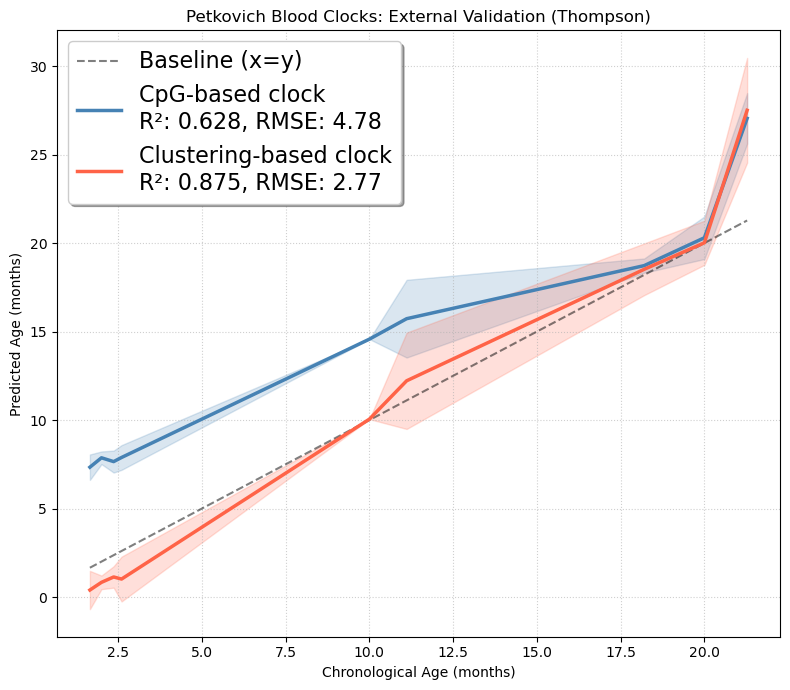

In [36]:
def plot_clocks_external(
    pred_cpg,
    pred_reg,
    y,
    r2_cpg,
    r2_reg,
    rmse_cpg,
    rmse_reg,
    save_path="../outputs/01_petkovich_blood_clocks/petkovich_on_thompson.png",
):
    plt.figure(figsize=(8, 7))
    lims = [y.min(), y.max()]
    plt.plot(lims, lims, "--k", alpha=0.5, label="Baseline (x=y)")
    for pred, name, color, r2, rmse in [
        (pred_cpg, "CpG-based clock", "steelblue", r2_cpg, rmse_cpg),
        (pred_reg, "Clustering-based clock", "tomato", r2_reg, rmse_reg),
    ]:
        stats = pd.Series(pred, index=y.index).groupby(y).agg(["mean", "std"]).fillna(0)
        lbl = f"{name}\nR²: {r2:.3f}, RMSE: {rmse:.2f}"
        plt.plot(stats.index, stats["mean"], color=color, label=lbl, lw=2.5)
        plt.fill_between(
            stats.index,
            stats["mean"] - stats["std"],
            stats["mean"] + stats["std"],
            alpha=0.2,
            color=color,
        )
    plt.xlabel("Chronological Age (months)")
    plt.ylabel("Predicted Age (months)")
    plt.title("Petkovich Blood Clocks: External Validation (Thompson)")
    plt.legend(loc="upper left", frameon=True, shadow=True, fontsize=16)
    plt.grid(True, ls=":", alpha=0.6)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_clocks_external(pred_cpg, pred_reg, y_thompson, r2_cpg, r2_reg, rmse_cpg, rmse_reg)

### Evaluate the performance of the Petkovich cluster-based and CpG-based clocks on the Thompson dataset stratified by sex

Note: all the mice in the Petkovich dataset are male, while the Thompson dataset contains both male and female mice.

/data/user/pgrobush/miniforge3/envs/semen/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LassoCV was fitted with feature names
  warnings.warn(
/data/user/pgrobush/miniforge3/envs/semen/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LassoCV was fitted with feature names
  warnings.warn(


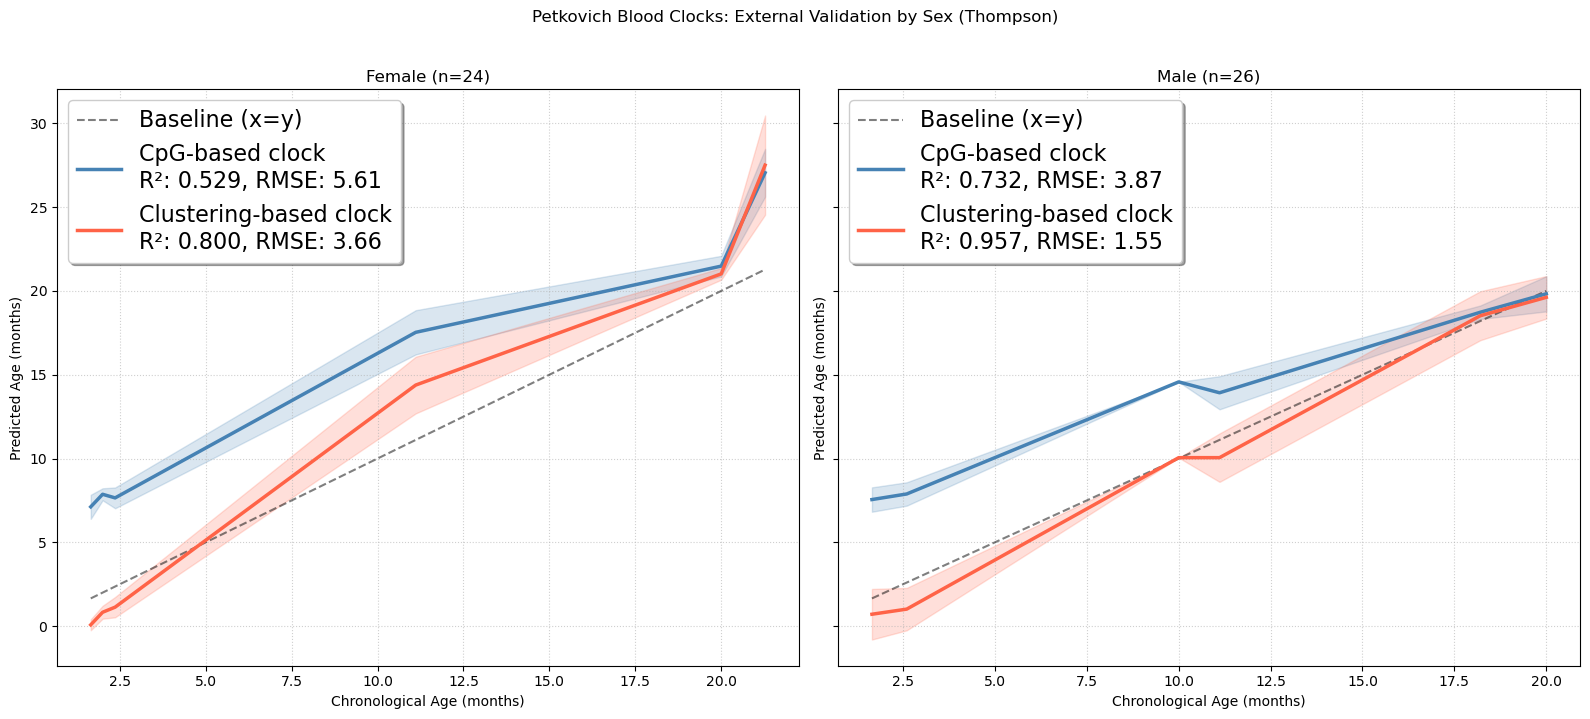

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for ax, sex in zip(axes, ["Female", "Male"]):
    sex_idx = thompson_meta[thompson_meta["Sex"] == sex].index
    sex_pos = [thompson_meta.index.get_loc(i) for i in sex_idx]
    y_sex = thompson_meta.loc[sex_idx, "Age"]

    pred_cpg_sex = final_model_cpg.predict(X_thompson_cpg_np[sex_pos])
    pred_reg_sex = final_model_reg.predict(X_thompson_reg_np[sex_pos])

    r2_cpg_sex = r2_score(y_sex, pred_cpg_sex)
    r2_reg_sex = r2_score(y_sex, pred_reg_sex)
    rmse_cpg_sex = root_mean_squared_error(y_sex, pred_cpg_sex)
    rmse_reg_sex = root_mean_squared_error(y_sex, pred_reg_sex)

    lims = [y_sex.min(), y_sex.max()]
    ax.plot(lims, lims, "--k", alpha=0.5, label="Baseline (x=y)")

    for pred, name, color, r2, rmse in [
        (pred_cpg_sex, "CpG-based clock", "steelblue", r2_cpg_sex, rmse_cpg_sex),
        (pred_reg_sex, "Clustering-based clock", "tomato", r2_reg_sex, rmse_reg_sex),
    ]:
        stats = (
            pd.Series(pred, index=y_sex.index)
            .groupby(y_sex)
            .agg(["mean", "std"])
            .fillna(0)
        )
        lbl = f"{name}\nR²: {r2:.3f}, RMSE: {rmse:.2f}"
        ax.plot(stats.index, stats["mean"], color=color, label=lbl, lw=2.5)
        ax.fill_between(
            stats.index,
            stats["mean"] - stats["std"],
            stats["mean"] + stats["std"],
            alpha=0.2,
            color=color,
        )

    ax.set_title(f"{sex} (n={len(sex_idx)})")
    ax.set_xlabel("Chronological Age (months)")
    ax.set_ylabel("Predicted Age (months)")
    ax.legend(loc="upper left", frameon=True, shadow=True, fontsize=16)
    ax.grid(True, ls=":", alpha=0.6)

fig.suptitle("Petkovich Blood Clocks: External Validation by Sex (Thompson)", y=1.02)
plt.tight_layout()
plt.savefig(
    "../outputs/01_petkovich_blood_clocks/petkovich_on_thompson_by_sex.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()